# Spectral dispersion and K-sequence traces (miniature)

This notebook visualises how astronomical scenes are dispersed into 2-D
spectrograms by the four-angle Euclid K-sequence grism exposures.  It uses
the `ForwardModel` and `KSequence` from the `spectangle` package and the
complexity-aware source / PSF / SED models introduced in notebook 02.

**Kernel:** select `Python (spectangle)` before running.

---
### K-sequence reminder
| Step | Grism | GWA tilt | Dispersion direction |
|:---:|---|---|---|
| 1 | RGS000 | +0° | +x |
| 2 | RGS180 | +4° | −x (slight +y tilt) |
| 3 | RGS000 | −4° | +x (slight −y tilt) |
| 4 | RGS180 | +0° | −x |

The `KSequence.miniature(n_lambda)` factory scales the dispersion so that the
full 9250–18 500 Å bandpass fits in ≈ 64 pixels along the dispersion axis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from spectangle.simulations.forward import ForwardModel
from spectangle.physics.dispersion import KSequence
from spectangle.physics.psf import make_psf
from spectangle.simulations.sed import make_sed
from spectangle.simulations.sources import make_source

print('Imports OK')

Imports OK


---
## 1  Build a multi-source scene cube

We place three sources in a 64 × 64 field:

| Source | Type | SED | Position |
|---|---|---|---|
| A — hot star | `PointSource` (C2) | Blackbody 10 000 K | (21, 32) |
| B — cool galaxy | `SersicSource` (C1) | Blackbody 4 500 K | (42, 20) |
| C — planetary nebula | `RingNebula` (C2) | Gaussian line at 13 700 Å | (48, 44) |

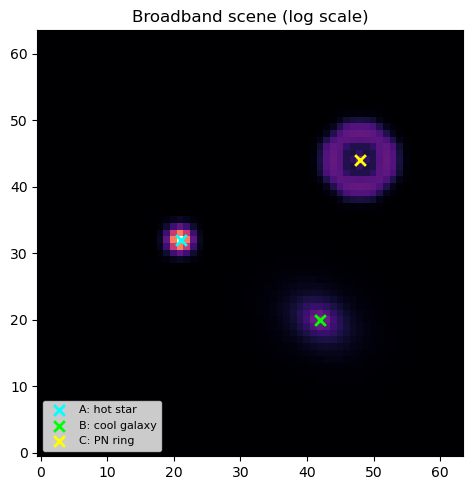

Cube shape: (128, 64, 64)  — min: -6.48122e-13   max: 8.365662e-05


In [2]:
ny, nx = 64, 64
n_lambda = 128
wav = np.linspace(9250, 18500, n_lambda)  # Å

# Source definitions: (label, source_type, complexity, source_kwargs, sed, amplitude, xc, yc)
source_defs = [
    ('A: hot star',    'point',  2, {},
     make_sed(1, temperature_K=10000), 1.0, 21.0, 32.0),
    ('B: cool galaxy', 'galaxy', 1, dict(r_e_pixels=4.0, sersic_n=1.5, ellipticity=0.7, pa_deg=30.0),
     make_sed(1, temperature_K=4500),  0.6, 42.0, 20.0),
    ('C: PN ring',     'nebula', 2, dict(inner_r_pixels=3.0, outer_r_pixels=5.5, central_fraction=0.05),
     make_sed(0, peak_wavelength_AA=13700, sigma_AA=200), 1.2, 48.0, 44.0),
]

cube = np.zeros((n_lambda, ny, nx), dtype=np.float32)
for label, stype, comp, skw, sed, amp, xc, yc in source_defs:
    morphology = make_source(stype, comp, **skw).render(ny, nx, xc, yc)  # (ny, nx)
    flux = sed(wav)                                                        # (n_lambda,)
    cube += amp * flux[:, np.newaxis, np.newaxis] * morphology[np.newaxis, :, :]

# Convolve each slice with PSF (complexity-1 Moffat)
psf = make_psf(1, fwhm_pixels=1.6, beta=3.5)
cube = psf.convolve_cube(cube)

# Broadband image
broadband = cube.sum(axis=0)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(np.log1p(broadband * 1e4), origin='lower', cmap='magma')
ax.set_title('Broadband scene (log scale)')
trace_colors = ['cyan', 'lime', 'yellow']
for (label, *_, xc, yc), col in zip(source_defs, trace_colors):
    ax.scatter(xc, yc, s=60, color=col, marker='x', linewidths=2, label=label)
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()
print('Cube shape:', cube.shape, ' — min:', cube.min(), '  max:', cube.max())

---
## 2  Forward model — 1st-order-only spectrograms

The `ForwardModel` disperses the cube along all four K-sequence angles and
returns a `(4, ny+2·pad_y, nx+2·pad_x)` array of simulated detector images.

Spectrograms shape: (4, 70, 128)
pad_x = 32   pad_y = 3


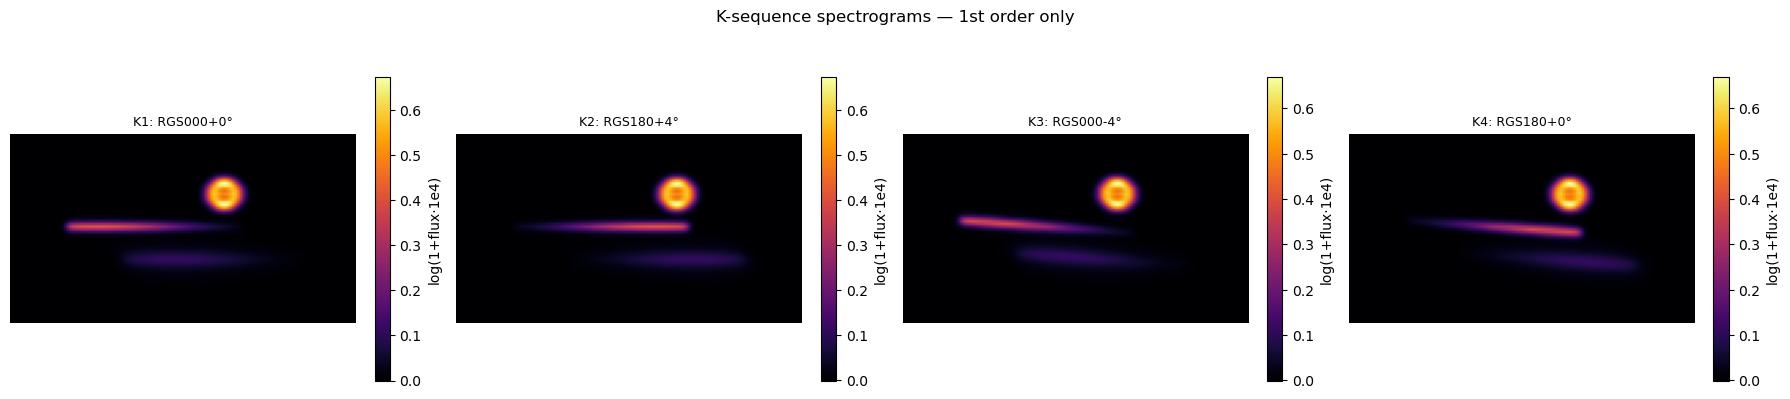

In [3]:
kseq = KSequence.miniature(n_lambda)
fwd  = ForwardModel(ksequence=kseq, psf_model=psf, image_shape=(ny, nx), orders=[1])

specs = fwd(cube, wav)   # shape: (4, ny+2*pad_y, nx+2*pad_x)
print('Spectrograms shape:', specs.shape)
print('pad_x =', fwd.pad_x, '  pad_y =', fwd.pad_y)

k_names = ['K1: RGS000+0°', 'K2: RGS180+4°', 'K3: RGS000-4°', 'K4: RGS180+0°']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for k in range(4):
    im = axes[k].imshow(np.log1p(specs[k] * 1e4), origin='lower', cmap='inferno')
    axes[k].set_title(k_names[k], fontsize=9)
    axes[k].axis('off')
    fig.colorbar(im, ax=axes[k], fraction=0.04, label='log(1+flux·1e4)')
plt.suptitle('K-sequence spectrograms — 1st order only', y=1.01)
plt.tight_layout()
plt.show()

---
## 3  Dispersion trace overlay

For each source position we compute the expected linear dispersion trace using
`DispersionModel.wavelength_to_offset()` and overlay it on the spectrogram.

**API note:** `wavelength_to_offset(lam)` returns an `Offset` object with
`.delta_x` and `.delta_y` attributes (pixel offsets from the source position).
The padded coordinate of source `(xc, yc)` is `(xc + pad_x, yc + pad_y)`.

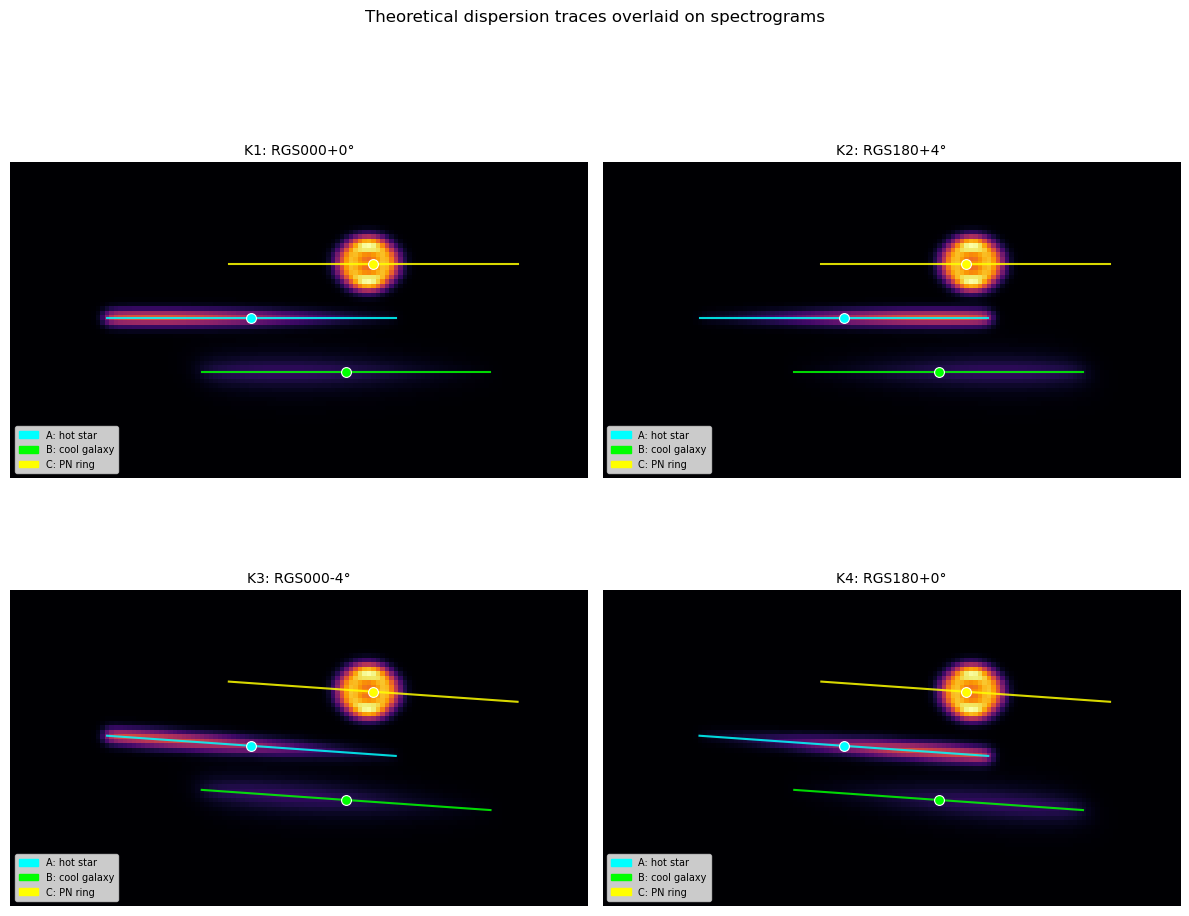

In [4]:
pad_x, pad_y = fwd.pad_x, fwd.pad_y

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for k, disp in enumerate(kseq):
    ax = axes[k]
    ax.imshow(np.log1p(specs[k] * 1e4), origin='lower', cmap='inferno')
    ax.set_title(k_names[k], fontsize=10)
    ax.axis('off')

    legend_handles = []
    for (label, *_, xc, yc), col in zip(source_defs, trace_colors):
        # compute pixel trace: source position (padded) + dispersion offset at each λ
        trace_x = np.array([
            xc + pad_x + disp.wavelength_to_offset(lam).delta_x
            for lam in wav
        ])
        trace_y = np.array([
            yc + pad_y + disp.wavelength_to_offset(lam).delta_y
            for lam in wav
        ])
        ax.plot(trace_x, trace_y, color=col, lw=1.5, alpha=0.85)
        # mark source position
        ax.scatter(xc + pad_x, yc + pad_y, s=50, color=col, marker='o',
                   edgecolors='white', linewidths=0.8, zorder=5)
        legend_handles.append(mpatches.Patch(color=col, label=label))

    ax.legend(handles=legend_handles, fontsize=7, loc='lower left')

plt.suptitle('Theoretical dispersion traces overlaid on spectrograms', y=1.01)
plt.tight_layout()
plt.show()

---
## 4  Wavelength-position mapping along the trace

Show the x-pixel position of each source's trace at K-step 1 (RGS000+0°)
as a function of wavelength, and mark the spectral extent spanned on the
detector.

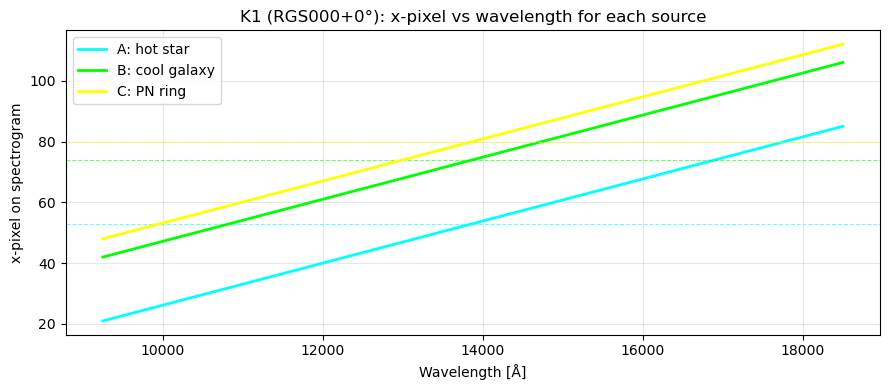

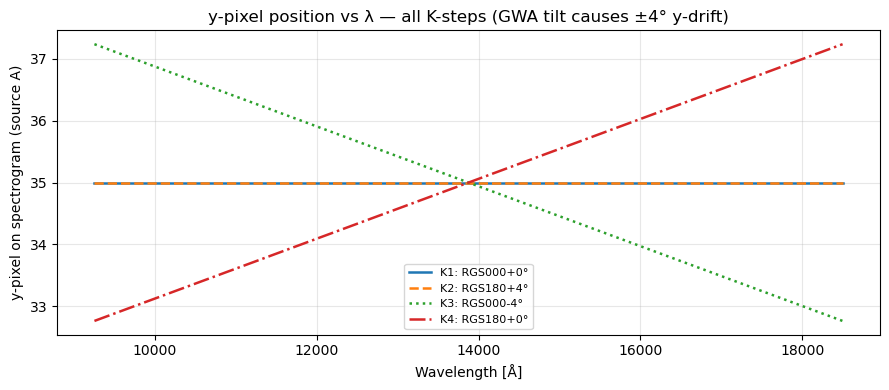

In [5]:
disp0 = kseq[0]  # K1: RGS000+0°

fig, ax = plt.subplots(figsize=(9, 4))
for (label, *_, xc, yc), col in zip(source_defs, trace_colors):
    trace_x = np.array([
        xc + pad_x + disp0.wavelength_to_offset(lam).delta_x
        for lam in wav
    ])
    ax.plot(wav, trace_x, color=col, lw=2, label=label)
    ax.axhline(xc + pad_x, color=col, lw=0.8, ls='--', alpha=0.6)   # zero-order position

ax.set_xlabel('Wavelength [Å]')
ax.set_ylabel('x-pixel on spectrogram')
ax.set_title('K1 (RGS000+0°): x-pixel vs wavelength for each source')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Also show y-pixel (should be ~constant for K1, small tilt for K2/K3)
fig, ax = plt.subplots(figsize=(9, 4))
linestyles = ['-', '--', ':', '-.']
for k_idx, disp in enumerate(kseq):
    # Use only source A for clarity
    label_A, *_, xc_A, yc_A = source_defs[0]
    trace_y = np.array([
        yc_A + pad_y + disp.wavelength_to_offset(lam).delta_y
        for lam in wav
    ])
    ax.plot(wav, trace_y, ls=linestyles[k_idx], lw=1.8, label=k_names[k_idx])

ax.set_xlabel('Wavelength [Å]')
ax.set_ylabel('y-pixel on spectrogram (source A)')
ax.set_title('y-pixel position vs λ — all K-steps (GWA tilt causes ±4° y-drift)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5  Multi-order spectrograms (orders 0, 1, 2)

Adding the 0th order (undispersed 'blob') and the 2nd order (twice the 1st
order offset) reveals how they overlap with neighbouring sources and the 1st
order traces — the core confusion problem that the neural network must solve.

> **Note on shapes:** each `ForwardModel` computes its own padding based on
> the maximum dispersion offset for its active orders.  Multi-order padding is
> therefore larger than 1st-order-only padding.  We centre-crop the multi-order
> spectrograms to the 1st-order footprint for side-by-side comparison.

1st-order spectrograms shape: (4, 70, 128)
Multi-order spectrograms shape: (4, 74, 192)


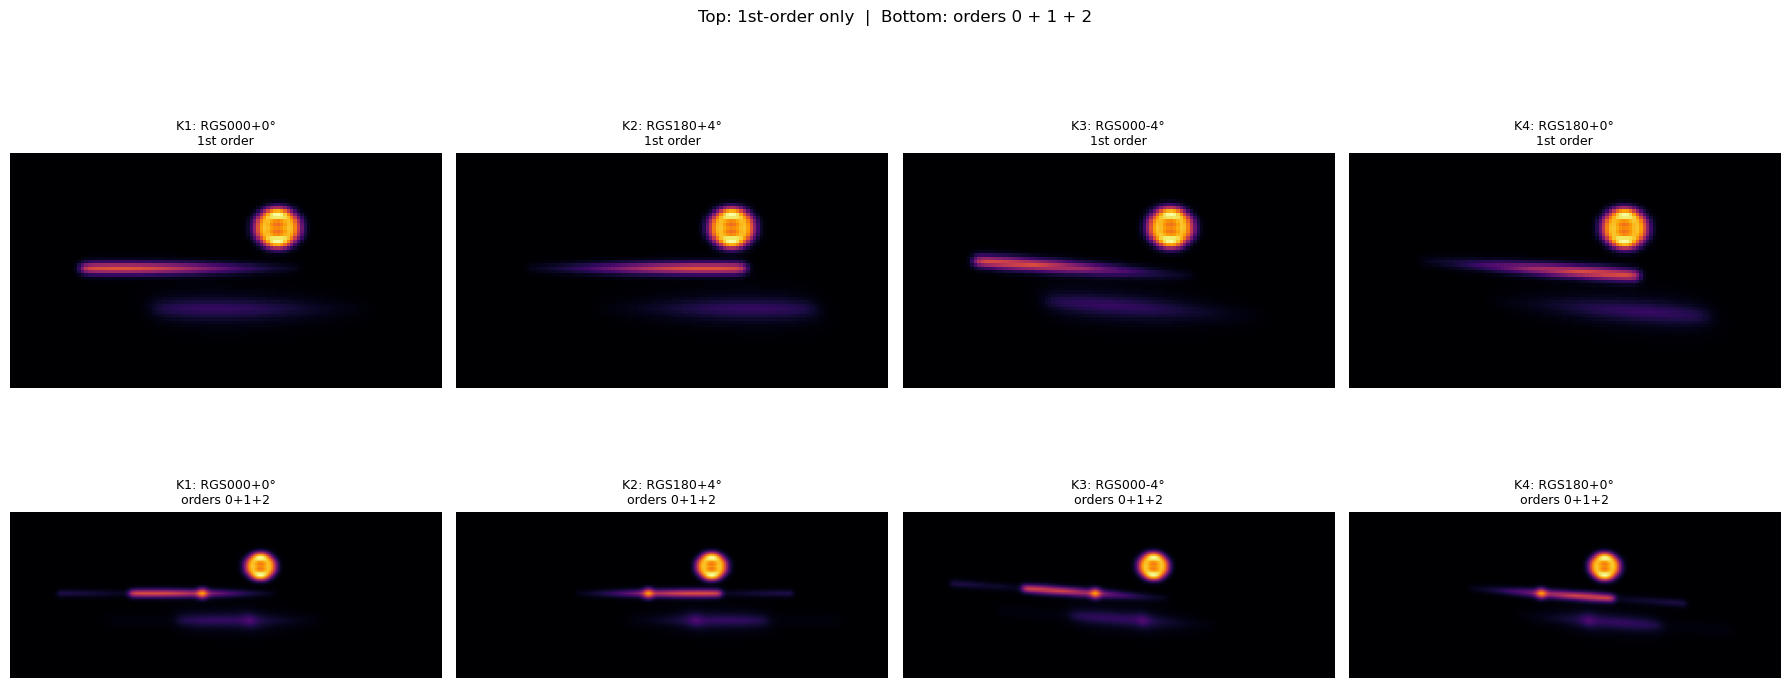

In [6]:
fwd_multi = ForwardModel(ksequence=kseq, psf_model=psf, image_shape=(ny, nx), orders=[0, 1, 2])
specs_multi = fwd_multi(cube, wav)
print('1st-order spectrograms shape:', specs.shape)
print('Multi-order spectrograms shape:', specs_multi.shape)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for k in range(4):
    # 1st order only (top row)
    axes[0, k].imshow(np.log1p(specs[k] * 1e4), origin='lower', cmap='inferno')
    axes[0, k].set_title(f'{k_names[k]}\n1st order', fontsize=9)
    axes[0, k].axis('off')
    # multi-order (bottom row)
    axes[1, k].imshow(np.log1p(specs_multi[k] * 1e4), origin='lower', cmap='inferno')
    axes[1, k].set_title(f'{k_names[k]}\norders 0+1+2', fontsize=9)
    axes[1, k].axis('off')

plt.suptitle('Top: 1st-order only  |  Bottom: orders 0 + 1 + 2', y=1.01)
plt.tight_layout()
plt.show()

### 5b  Difference image: order confusion

The residual between the multi-order and 1st-order-only spectrograms
isolates the contamination from 0th and 2nd orders.  Because the two
`ForwardModel` instances have different padding, we centre-crop the larger
multi-order array to match the 1st-order footprint before subtracting.

specs shape:        (4, 70, 128)
specs_multi crop:   (4, 70, 128)  (centre of (4, 74, 192))


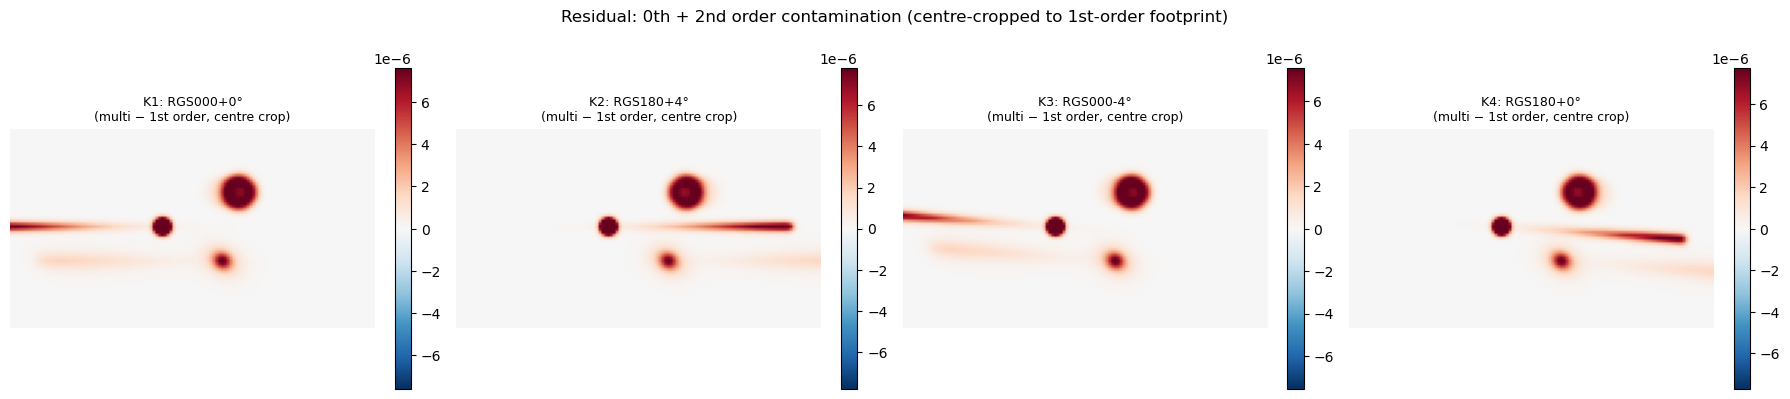

In [7]:
# specs       shape: (4, ny+2*pad_y_1,  nx+2*pad_x_1)   — 1st-order padding
# specs_multi shape: (4, ny+2*pad_y_m,  nx+2*pad_x_m)   — multi-order padding (larger)
# Centre-crop specs_multi to the same spatial footprint as specs.
ny1, nx1 = specs.shape[1], specs.shape[2]
nym, nxm = specs_multi.shape[1], specs_multi.shape[2]
cy0 = (nym - ny1) // 2
cx0 = (nxm - nx1) // 2
specs_multi_crop = specs_multi[:, cy0:cy0 + ny1, cx0:cx0 + nx1]

print(f'specs shape:        {specs.shape}')
print(f'specs_multi crop:   {specs_multi_crop.shape}  (centre of {specs_multi.shape})')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for k in range(4):
    residual = specs_multi_crop[k] - specs[k]
    vmax = np.percentile(np.abs(residual), 99)
    im = axes[k].imshow(residual, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[k].set_title(f'{k_names[k]}\n(multi − 1st order, centre crop)', fontsize=9)
    axes[k].axis('off')
    fig.colorbar(im, ax=axes[k], fraction=0.04)
plt.suptitle('Residual: 0th + 2nd order contamination (centre-cropped to 1st-order footprint)', y=1.01)
plt.tight_layout()
plt.show()

---
## 6  SNR estimate: trace brightness vs background

Extract a 1-D brightness profile along the dispersion axis (K1) at the
y-position of each source, and compare them to quantify the
effective SNR in a noiseless simulation.

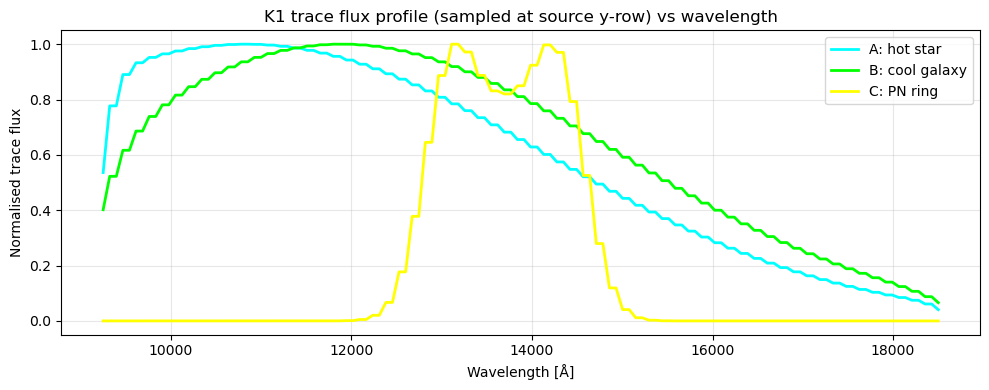

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
for (label, *_, xc, yc), col in zip(source_defs, trace_colors):
    # row nearest to source y-centre (in padded coords)
    row = int(np.clip(round(yc + pad_y), 0, specs.shape[1] - 1))
    # expected x-positions of the trace at each wavelength
    x_offset_arr = np.array([
        xc + pad_x + disp0.wavelength_to_offset(lam).delta_x
        for lam in wav
    ])
    x_idx = np.clip(np.round(x_offset_arr).astype(int), 0, specs.shape[2] - 1)
    trace_flux = specs[0, row, x_idx]   # brightness along the trace
    ax.plot(wav, trace_flux / (trace_flux.max() + 1e-12), color=col, lw=2, label=label)

ax.set_xlabel('Wavelength [Å]')
ax.set_ylabel('Normalised trace flux')
ax.set_title('K1 trace flux profile (sampled at source y-row) vs wavelength')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Takeaways

- `DispersionModel.wavelength_to_offset(λ)` returns an `Offset` object with
  `.delta_x` and `.delta_y` attributes (pixel offset from the source position).
  The padded source coordinates are `(xc + pad_x, yc + pad_y)`.

- `ForwardModel.pad_x` / `pad_y` depend on **which orders are active**: adding
  0th and 2nd orders increases the padding (larger output array).
  Always centre-crop when comparing arrays from different `ForwardModel` instances.

- The four K-sequence angles provide four distinct dispersion directions:
  K1 and K3 disperse along +x, K2 and K4 along −x.  K2/K3 have a small
  ±4° GWA tilt that causes a gentle y-drift with wavelength.

- Multi-order contamination (0th and 2nd) creates additional blended signal
  — the PINN loss function must incorporate the dispersion law explicitly to
  account for this.

### Next steps
- **Notebook `../training_testing/01_train_unet_on_mini.ipynb`**: train the U-Net on the HDF5
  dataset generated in notebook 01.
- **Notebook `../training_testing/03_train_pinn_on_mini.ipynb`**: train the physics-informed model
  with the K-sequence dispersion law built into the loss function.